In [1]:
import requests
from pathlib import Path

utility_files = ["cmd_helper.py", "notebook_utils.py", "pip_helper.py"]
base_utility_url = "https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/"

for utility in utility_files:
    if not Path(utility).exists():
        r = requests.get(base_utility_url + utility)
        with open(utility, "w") as f:
            f.write(r.text)

helper_files = ["ov_deepseek_vl_helper.py", "modeling_helper.py", "gradio_helper.py"]
base_helper_url = "https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/notebooks/deepseek-vl2/"

for helper in helper_files:
    if not Path(helper).exists():
        r = requests.get(base_helper_url + helper)
        with open(helper, "w") as f:
            f.write(r.text)

In [2]:
from pip_helper import pip_install

pip_install("-U", "openvino>=2025.0", "nncf>=2.15")
pip_install("torch>=2.1", "torchvision", "gradio>=4.19", "einops", "transformers>=4.47",  "timm>=0.9.16", "accelerate", "sentencepiece", "attrdict",
            "mdtex2html",
            "pypinyin",
            "tiktoken",
            "tqdm",
            "colorama",
            "Pygments",
            "markdown",
            "--extra-index-url", "https://download.pytorch.org/whl/cpu")

In [3]:
from ov_deepseek_vl_helper import prepare_model_repo

prepare_model_repo()

<frozen importlib.util>:247: DeprecationWarning: The `openvino.runtime` module is deprecated and will be removed in the 2026.0 release. Please replace `openvino.runtime` with `openvino`.


In [4]:
from ov_deepseek_vl_helper import model_ids
import ipywidgets as widgets

model_selector = widgets.Dropdown(options=model_ids, value=model_ids[0])

model_selector

Dropdown(options=('deepseek-ai/deepseek-vl2-tiny', 'deepseek-ai/deepseek-vl2-small', 'deepseek-ai/deepseek-vl2…

In [5]:
from ov_deepseek_vl_helper import convert_deepseek_vl

# uncomment the line to see conversion code
# ??convert_deepseek_vl

In [6]:
model_path = convert_deepseek_vl(model_selector.value)

Python version is above 3.10, patching the collections module.


2025-02-19 14:50:02.100741: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-19 14:50:02.114610: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739962202.129796 3145940 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739962202.134176 3145940 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-19 14:50:02.151193: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Model already converted and can be found in deepseek-vl2-tiny


In [7]:
from ov_deepseek_vl_helper import OVDeepseekVLV2ForCausalLM

# uncommet the line to see model class code
# ??OVDeepseekVLV2ForCausalLM

In [8]:
from notebook_utils import device_widget

device = device_widget(default="CPU", exclude=["NPU"])

device

Dropdown(description='Device:', options=('CPU', 'AUTO'), value='CPU')

In [9]:
from deepseek_vl2.models import DeepseekVLV2Processor

ov_model = OVDeepseekVLV2ForCausalLM(model_path, device.value)
processor = DeepseekVLV2Processor.from_pretrained(model_path)

Some kwargs in processor config are unused and will not have any effect: downsample_ratio, image_mean, mask_prompt, image_std, sft_format, ignore_id, patch_size, pad_token, add_special_token, image_token, candidate_resolutions, normalize. 


Add pad token = ['<｜▁pad▁｜>'] to the tokenizer
<｜▁pad▁｜>:2
Add image token = ['<image>'] to the tokenizer
<image>:128815
Add grounding-related tokens = ['<|ref|>', '<|/ref|>', '<|det|>', '<|/det|>', '<|grounding|>'] to the tokenizer with input_ids
<|ref|>:128816
<|/ref|>:128817
<|det|>:128818
<|/det|>:128819
<|grounding|>:128820
Add chat tokens = ['<|User|>', '<|Assistant|>'] to the tokenizer with input_ids
<|User|>:128821
<|Assistant|>:128822



In [10]:
import PIL
import re
from deepseek_vl2.serve.app_modules.presets import (
    ALREADY_CONVERTED_MARK,
    BOX2COLOR,
    MAX_IMAGE_SIZE,
    MIN_IMAGE_SIZE
)

def parse_ref_bbox(response, image: PIL.Image.Image):
    try:
        image = image.copy()
        image_h, image_w = image.size
        draw = PIL.ImageDraw.Draw(image)

        ref = re.findall(r'<\|ref\|>.*?<\|/ref\|>', response)
        bbox = re.findall(r'<\|det\|>.*?<\|/det\|>', response)
        assert len(ref) == len(bbox)

        if len(ref) == 0:
            return None

        boxes, labels = [], []
        for box, label in zip(bbox, ref):
            box = box.replace('<|det|>', '').replace('<|/det|>', '')
            label = label.replace('<|ref|>', '').replace('<|/ref|>', '')
            box = box[1:-1]
            for onebox in re.findall(r'\[.*?\]', box):
                boxes.append(eval(onebox))
                labels.append(label)

        for indice, (box, label) in enumerate(zip(boxes, labels)):
            box = (
                int(box[0] / 999 * image_h),
                int(box[1] / 999 * image_w),
                int(box[2] / 999 * image_h),
                int(box[3] / 999 * image_w),
            )

            box_color = BOX2COLOR[indice % len(BOX2COLOR.keys())]
            box_width = 3
            draw.rectangle(box, outline=box_color, width=box_width)

            text_x = box[0]
            text_y = box[1] - 20
            text_color = box_color
            font = PIL.ImageFont.truetype("DeepSeek-VL2/deepseek_vl2/serve/assets/simsun.ttc", size=20)
            draw.text((text_x, text_y), label, font=font, fill=text_color)

        # print(f"boxes = {boxes}, labels = {labels}, re-render = {image}")
        return image
    except Exception as e:
        return None


You're using a LlamaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


The giraffe at the back.[[580, 270, 999, 904]]


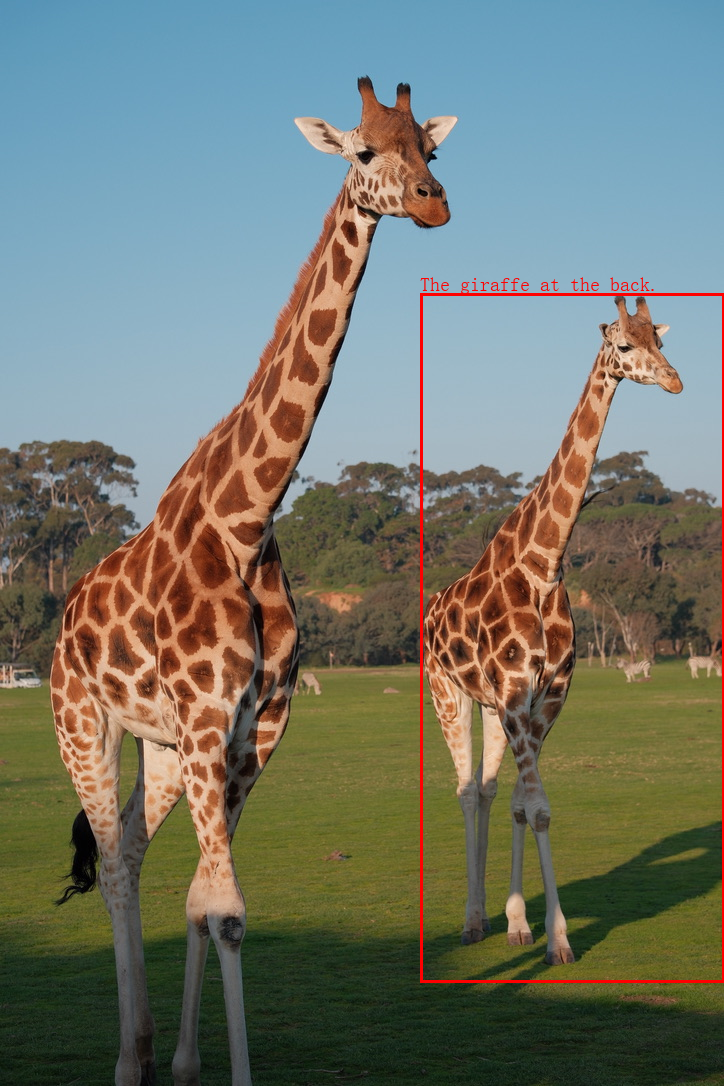

In [11]:
from transformers import TextStreamer

def load_pil_images(conversations):
    """

    Args:
        conversations (List[Dict[str, str]]): the conversations with a list of messages. An example is :
            [
                {
                    "role": "User",
                    "content": "<image>\nExtract all information from this image and convert them into markdown format.",
                    "images": ["./examples/table_datasets.png"]
                },
                {"role": "Assistant", "content": ""},
            ]

    Returns:
        pil_images (List[PIL.Image.Image]): the list of PIL images.

    """

    pil_images = []

    for message in conversations:
        if "images" not in message:
            continue

        for image_path in message["images"]:
            pil_img = PIL.Image.open(image_path)
            pil_img = pil_img.convert("RGB")
            pil_images.append(pil_img)

    return pil_images


conversation = [
    {
        "role": "<|User|>",
        "content": "<image>\n<|ref|>The giraffe at the back.<|/ref|>.",
        "images": ["DeepSeek-VL2/images/visual_grounding_1.jpeg"],
    },
    {"role": "<|Assistant|>", "content": ""},
]

pil_images = load_pil_images(conversation)
prepare_inputs = processor(
    conversations=conversation,
    images=pil_images,
    force_batchify=True,
    system_prompt=""
)

inputs_embeds = ov_model.prepare_inputs_embeds(**prepare_inputs)

# run the model to get the response
outputs = ov_model.language_model.generate(
    inputs_embeds=inputs_embeds,
    attention_mask=None,
    pad_token_id=processor.tokenizer.eos_token_id,
    bos_token_id=processor.tokenizer.bos_token_id,
    eos_token_id=processor.tokenizer.eos_token_id,
    past_key_values=None,
    input_ids=None,
    max_new_tokens=512,
    do_sample=False,
    use_cache=True,
    streamer=TextStreamer(processor.tokenizer, skip_special_tokens=True)
)

answer = processor.tokenizer.batch_decode(outputs, skip_special_tokens=False)

vg_image = parse_ref_bbox(answer[0], image=pil_images[-1])

if vg_image is not None:
    display(vg_image)

You should put the trash in the trash can[[623, 618, 821, 994]] that's next to the woman with blonde hair[[623, 618, 821, 994]] .


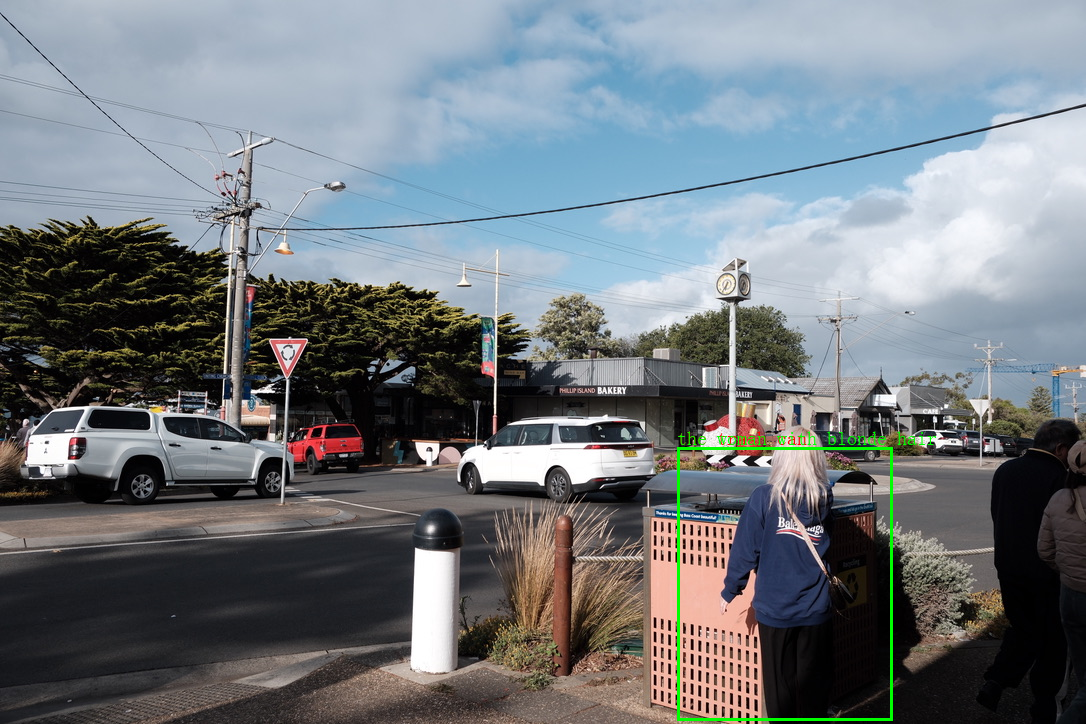

In [12]:
conversation = [
    {
        "role": "<|User|>",
        "content": "<image>\n<|grounding|>I want to throw out the trash now, what should I do?.",
        "images": ["DeepSeek-VL2/images/grounding_conversation_1.jpeg"],
    },
    {"role": "<|Assistant|>", "content": ""},
]

pil_images = load_pil_images(conversation)
prepare_inputs = processor(
    conversations=conversation,
    images=pil_images,
    force_batchify=True,
    system_prompt=""
)

inputs_embeds = ov_model.prepare_inputs_embeds(**prepare_inputs)

# run the model to get the response
outputs = ov_model.language_model.generate(
    inputs_embeds=inputs_embeds,
    attention_mask=None,
    pad_token_id=processor.tokenizer.eos_token_id,
    bos_token_id=processor.tokenizer.bos_token_id,
    eos_token_id=processor.tokenizer.eos_token_id,
    past_key_values=None,
    input_ids=None,
    max_new_tokens=512,
    do_sample=False,
    use_cache=True,
    streamer=TextStreamer(processor.tokenizer, skip_special_tokens=True)
)

answer = processor.tokenizer.batch_decode(outputs, skip_special_tokens=False)

vg_image = parse_ref_bbox(answer[0], image=pil_images[-1])

if vg_image is not None:
    display(vg_image)

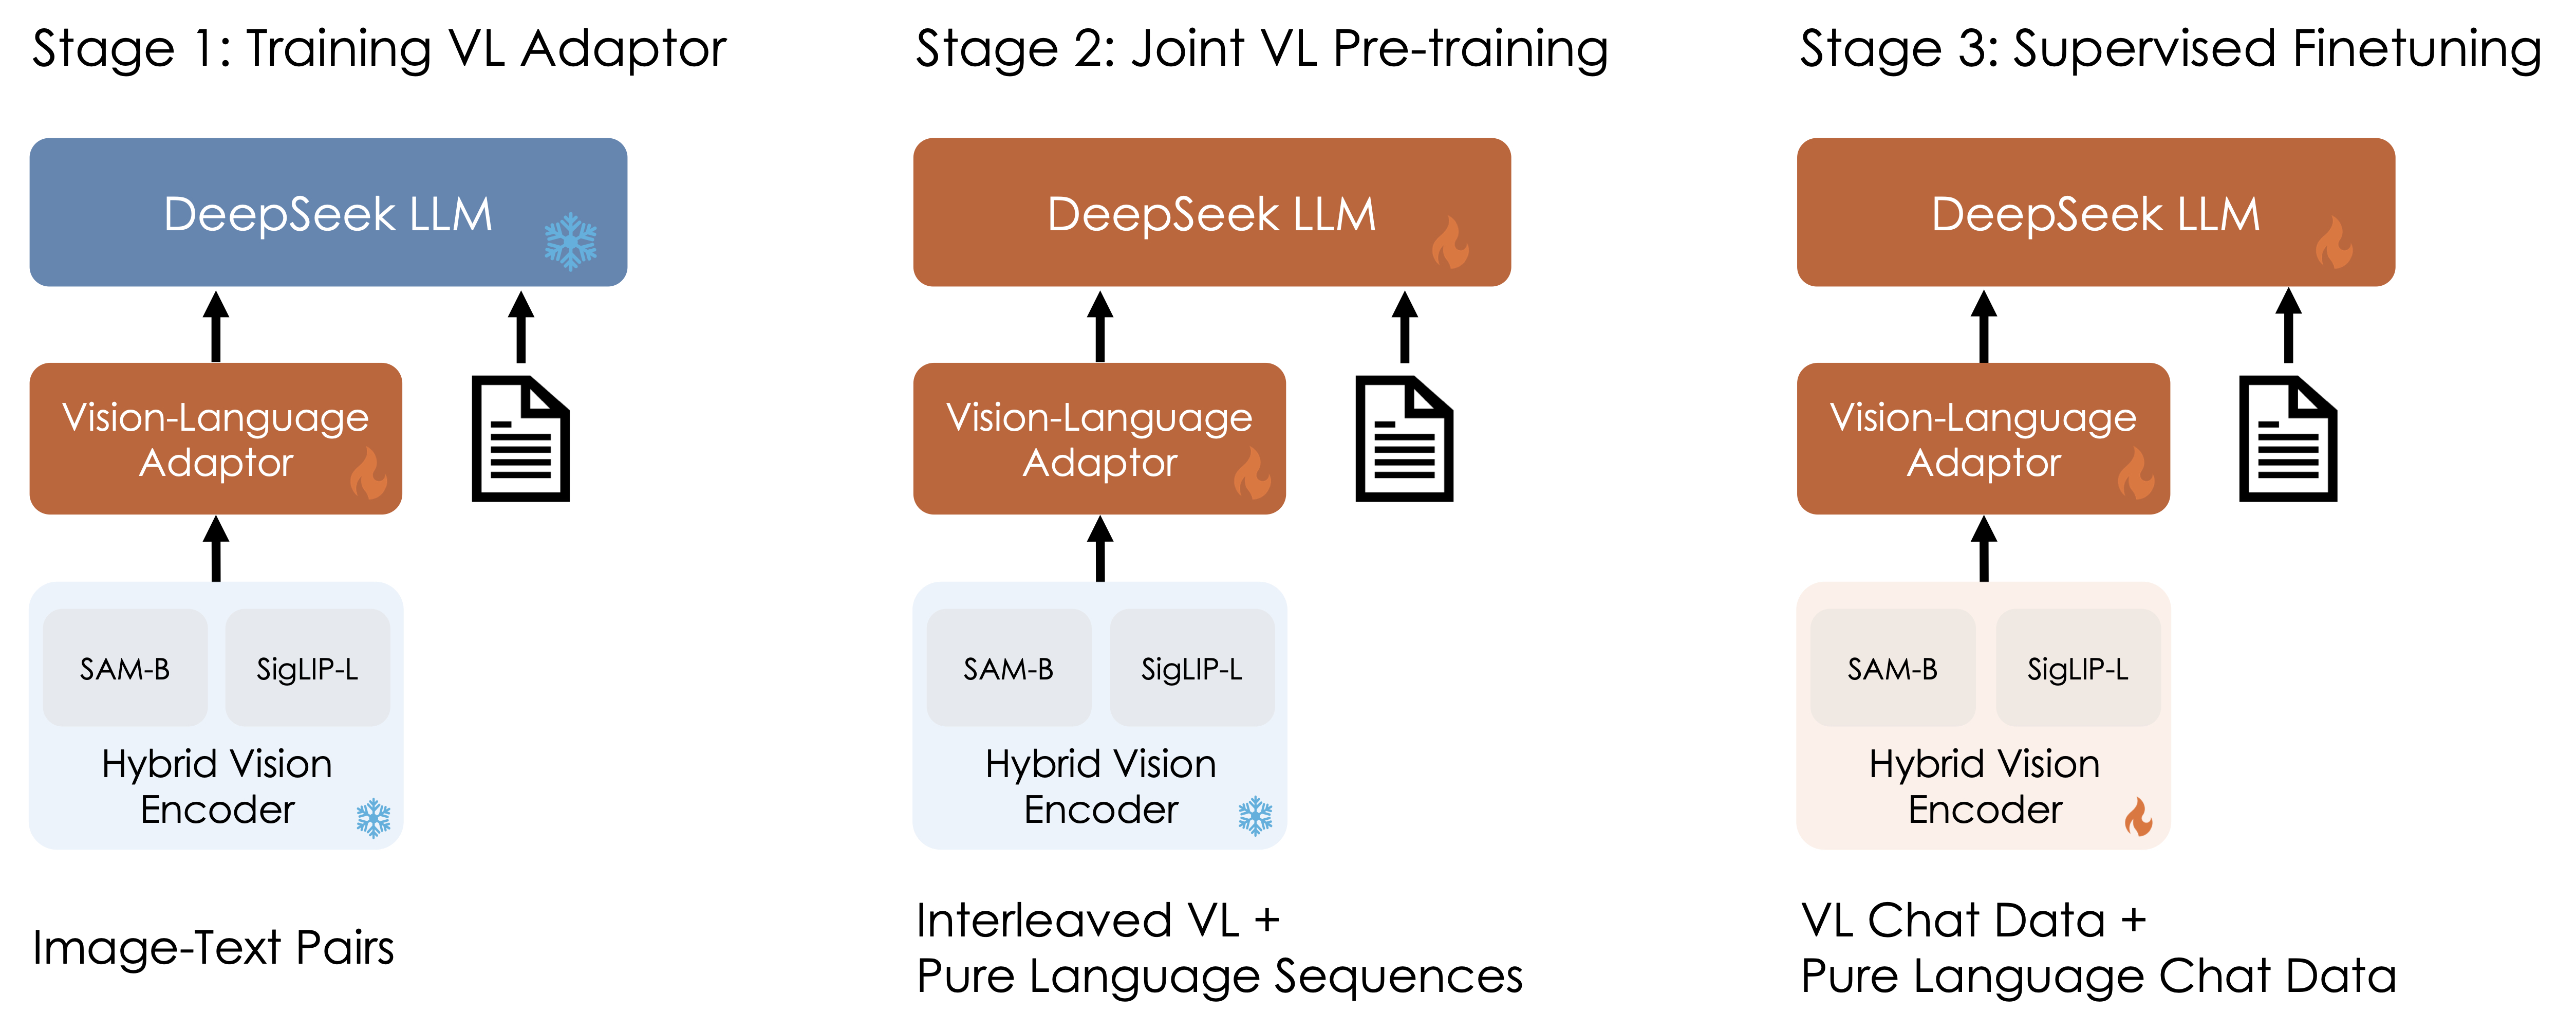

Stage 1: Training VL Adaptor - In this stage, an adaptation process occurs where the Vision-Language Adaptor (VLA) interacts with both Vision-Language Encoder (VLE) and Image-Text Pairs. The VLA processes these inputs using SAM-B and SigLIP-L models before being fed into the DeepSeek LLM for further processing.

Stage 2: Joint VL Pre-training - Here, the same architecture as Stage 1 is employed but now it involves interleaving Vision-Language sequences along with pure language chat data. This setup allows the VLA to learn from both types of input simultaneously, enhancing its ability to handle diverse linguistic inputs effectively.

Stage 3: Supervised Finetuning - Finally, the system undergoes supervised finetuning using VL Chat Data combined with pure language chat data. The VLA continues to process this new dataset while maintaining its pre-trained knowledge, ensuring that it remains adaptable and effective across different contexts and domains.


In [13]:
conversation = [
    {
        "role": "<|User|>",
        "content": "<image>\nDescribe each stage of this image in detail",
        "images": ["DeepSeek-VL2/images/vqa_1.jpg"],
    },
    {"role": "<|Assistant|>", "content": ""},
]

pil_images = load_pil_images(conversation)
prepare_inputs = processor(
    conversations=conversation,
    images=pil_images,
    force_batchify=True,
    system_prompt=""
)

display(pil_images[-1])
inputs_embeds = ov_model.prepare_inputs_embeds(**prepare_inputs)

# run the model to get the response
outputs = ov_model.language_model.generate(
    inputs_embeds=inputs_embeds,
    attention_mask=None,
    pad_token_id=processor.tokenizer.eos_token_id,
    bos_token_id=processor.tokenizer.bos_token_id,
    eos_token_id=processor.tokenizer.eos_token_id,
    past_key_values=None,
    input_ids=None,
    max_new_tokens=512,
    do_sample=False,
    use_cache=True,
    streamer=TextStreamer(processor.tokenizer, skip_special_tokens=True)
)

answer = processor.tokenizer.batch_decode(outputs, skip_special_tokens=False)

vg_image = parse_ref_bbox(answer[0], image=pil_images[-1])

if vg_image is not None:
    display(vg_image)